In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
pd.set_option("display.width", 200)

# Part 1 & 2: Dataset Understanding & Initial Exploration

In [2]:
# load the raw dataset and keep an unmodified copy for later comparison
df = pd.read_csv("AB_NYC_2019.csv")
original_df = pd.read_csv("AB_NYC_2019.csv")
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.68,-73.95,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70,-73.93,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81,-73.95,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.76,-73.99,Shared room,55,1,0,NaN,NaN,6,2


In [3]:
df.sample(random_state=42)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
879,317905,Come and go as you please in BKLN!,1631733,Jane,Brooklyn,Kensington,40.64,-73.98,Entire home/apt,89,3,62,2019-01-02,0.71,1,189


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [5]:
df.describe(include='number')

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,"48,895.00","48,895.00","48,895.00","48,895.00","48,895.00","48,895.00","48,895.00","38,843.00","48,895.00","48,895.00"
mean,"19,017,143.24","67,620,010.65",40.73,-73.95,152.72,7.03,23.27,1.37,7.14,112.78
std,"10,983,108.39","78,610,967.03",0.05,0.05,240.15,20.51,44.55,1.68,32.95,131.62
min,"2,539.00","2,438.00",40.50,-74.24,0.00,1.00,0.00,0.01,1.00,0.00
25%,"9,471,945.00","7,822,033.00",40.69,-73.98,69.00,1.00,1.00,0.19,1.00,0.00
50%,"19,677,284.00","30,793,816.00",40.72,-73.96,106.00,3.00,5.00,0.72,1.00,45.00
75%,"29,152,178.50","107,434,423.00",40.76,-73.94,175.00,5.00,24.00,2.02,2.00,227.00
max,"36,487,245.00","274,321,313.00",40.91,-73.71,"10,000.00","1,250.00",629.00,58.50,327.00,365.00


In [6]:
df.describe(exclude='number')

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48879,48874,48895,48895,48895,38843
unique,47905,11452,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21661,3920,25409,1413


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.duplicated(subset=["id"]).sum()

np.int64(0)

In [9]:
df.duplicated(subset=["host_id"]).sum()

np.int64(11438)

In [10]:
shape_before = df.shape

# Part 3: Data Quality Assessment

In [11]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [12]:
# find and drop near-duplicate listings using rounded coordinates plus key fields, keeping the most recently reviewed row
likely_duplicate_columns = ["host_id", "latitude_rounded", "longitude_rounded", "room_type", "price", "number_of_reviews", "availability_365"]
df["latitude_rounded"] = df["latitude"].round(2)
df["longitude_rounded"] = df["longitude"].round(2)

logical_duplicates_df = df[df.duplicated(subset=likely_duplicate_columns, keep=False)]
df = df.sort_values("last_review", ascending=False)
df = df.drop_duplicates(subset=likely_duplicate_columns, keep="first")
df = df.drop(columns=["latitude_rounded", "longitude_rounded"])


In [13]:
df[df["host_id"] == df["host_id"].value_counts().index[0]]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
41990,32634874,Sonder | Stock Exchange | Pristine 1BR + Sofa Bed,219517861,Sonder (NYC),Manhattan,Financial District,40.71,-74.01,Entire home/apt,248,2,7,2019-06-26,2.59,327,294
44670,34341994,Sonder | 116 John | Polished 2BR + Gym,219517861,Sonder (NYC),Manhattan,Financial District,40.71,-74.01,Entire home/apt,179,29,1,2019-06-24,1.00,327,339
41376,32224172,Sonder | Stock Exchange | Restful 1BR + Kitchen,219517861,Sonder (NYC),Manhattan,Financial District,40.71,-74.01,Entire home/apt,235,2,7,2019-06-24,1.52,327,306
41419,32237811,Sonder | Stock Exchange | Design Studio + Laundry,219517861,Sonder (NYC),Manhattan,Financial District,40.71,-74.01,Entire home/apt,205,2,10,2019-06-24,2.54,327,338
41404,32237138,Sonder | Stock Exchange | Lively Studio + Kitchen,219517861,Sonder (NYC),Manhattan,Financial District,40.71,-74.01,Entire home/apt,203,2,7,2019-06-24,1.88,327,338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47691,35871510,Sonder | 116 John | Vibrant Studio + Fitness Room,219517861,Sonder (NYC),Manhattan,Financial District,40.71,-74.01,Entire home/apt,135,29,0,NaN,NaN,327,339
47692,35871511,Sonder | 116 John | Vibrant 1BR + Fitness Room,219517861,Sonder (NYC),Manhattan,Financial District,40.71,-74.01,Entire home/apt,165,29,0,NaN,NaN,327,342
47693,35871515,Sonder | 116 John | Stunning 1BR + Rooftop,219517861,Sonder (NYC),Manhattan,Financial District,40.71,-74.01,Entire home/apt,165,29,0,NaN,NaN,327,347
47814,35936418,Sonder | 116 John | Polished Studio + Gym,219517861,Sonder (NYC),Manhattan,Financial District,40.71,-74.01,Entire home/apt,699,29,0,NaN,NaN,327,327


In [14]:
print("shape before removing duplicates: ", shape_before)
print("shape after: ", df.shape)
print("total removed rows = ", shape_before[0] - df.shape[0])

shape before removing duplicates:  (48895, 16)
shape after:  (48678, 16)
total removed rows =  217


In [15]:
# fix the last_review dtype, converting to real dates and turning unparsable values into NaT
df["last_review"] = pd.to_datetime(df["last_review"], errors='coerce')
df["last_review"]

48852   2019-07-08
42665   2019-07-08
44459   2019-07-08
44446   2019-07-08
44382   2019-07-08
           ...    
48890          NaT
48891          NaT
48892          NaT
48893          NaT
48894          NaT
Name: last_review, Length: 48678, dtype: datetime64[us]

In [16]:
numeric_columns = []
other_columns = []

for column in df.select_dtypes(include='number'):
    numeric_columns.append(column)

for column in df.select_dtypes(exclude='number'):
    other_columns.append(column)

print(f"Numeric columns: {len(numeric_columns)}")
print(f"Other columns: {len(other_columns)}")

Numeric columns: 10
Other columns: 6


In [17]:
filtered_columns_table = []

for column in df.columns:
    row = {
        "Column": column,
        "dtype": df[column].dtype,
        "non-null count": df[column].notna().sum(),
        "missing count": df[column].isnull().sum(),
        "unique count": df[column].nunique(),
        "example value": df[column].dropna().iloc[0]
    }

    filtered_columns_table.append(row)

filtered_df = pd.DataFrame(filtered_columns_table)
print(filtered_df)

                            Column           dtype  non-null count  missing count  unique count                            example value
0                               id           int64           48678              0         48678                                 36455809
1                             name             str           48662             16         47720  Cozy Private Room in Bushwick, Brooklyn
2                          host_id           int64           48678              0         37457                                 74162901
3                        host_name             str           48657             21         11452                                Christine
4              neighbourhood_group             str           48678              0             5                                 Brooklyn
5                    neighbourhood             str           48678              0           221                                 Bushwick
6                         latitude       

In [18]:
print(df["last_review"].max())
print(df["last_review"].min())


2019-07-08 00:00:00
2011-03-28 00:00:00


In [19]:
print((df.isna().sum() / len(df) * 100).round(2))

id                                0.00
name                              0.03
host_id                           0.00
host_name                         0.04
neighbourhood_group               0.00
neighbourhood                     0.00
latitude                          0.00
longitude                         0.00
room_type                         0.00
price                             0.00
minimum_nights                    0.00
number_of_reviews                 0.00
last_review                      20.34
reviews_per_month                20.34
calculated_host_listings_count    0.00
availability_365                  0.00
dtype: float64


In [20]:
# fill text-label nulls with "Unknown" and treat missing reviews_per_month as zero engagement
df["name"] = df["name"].fillna("Unknown")
df["host_name"] = df["host_name"].fillna("Unknown")
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [21]:
print((df.isna().sum() / len(df) * 100).round(2))

id                                0.00
name                              0.00
host_id                           0.00
host_name                         0.00
neighbourhood_group               0.00
neighbourhood                     0.00
latitude                          0.00
longitude                         0.00
room_type                         0.00
price                             0.00
minimum_nights                    0.00
number_of_reviews                 0.00
last_review                      20.34
reviews_per_month                 0.00
calculated_host_listings_count    0.00
availability_365                  0.00
dtype: float64


In [22]:
print("Rows with price <= 0:", (df["price"] <= 0).sum())
print("Rows with minimum_nights <= 0:", (df["minimum_nights"] <= 0).sum())
print("Rows with number_of_reviews < 0:", (df["number_of_reviews"] < 0).sum())
print("Rows with reviews_per_month < 0:", (df["reviews_per_month"] < 0).sum())
print("Rows with calculated_host_listings_count <= 0:", (df["calculated_host_listings_count"] <= 0).sum())
print("Rows with availability_365 outside 0-365:", (~df["availability_365"].between(0, 365)).sum())
print("Rows with latitude outside NYC bounds:", (~df["latitude"].between(40.4, 41.0)).sum())
print("Rows with longitude outside NYC bounds:", (~df["longitude"].between(-74.3, -73.6)).sum())


Rows with price <= 0: 11
Rows with minimum_nights <= 0: 0
Rows with number_of_reviews < 0: 0
Rows with reviews_per_month < 0: 0
Rows with calculated_host_listings_count <= 0: 0
Rows with availability_365 outside 0-365: 0
Rows with latitude outside NYC bounds: 0
Rows with longitude outside NYC bounds: 0


In [23]:
zero_or_negative_price_df = df[df["price"] <= 0]
zero_or_negative_price_df


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83,-73.89,Private room,0,2,55,2019-06-24,2.56,4,127
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68,-73.91,Private room,0,1,95,2019-06-23,4.35,6,222
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69,-73.91,Shared room,0,30,2,2019-06-22,0.11,6,333
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68,-73.91,Private room,0,1,95,2019-06-21,4.37,6,232
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68,-73.91,Private room,0,1,93,2019-06-15,4.28,6,176
26866,21304320,Best Coliving space ever! Shared room.,101970559,Sergii,Brooklyn,Bushwick,40.69,-73.91,Shared room,0,30,5,2019-05-24,0.26,6,139
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69,-73.92,Private room,0,2,16,2019-05-18,0.71,5,0
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69,-73.95,Private room,0,4,1,2018-01-06,0.05,4,28
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.71,-73.95,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72,-73.94,Private room,0,2,12,2017-10-27,0.53,2,0


In [24]:
# impute zero/negative prices with the median price from the closest matching group, falling back to broader groups if needed
df["price"] = df["price"].astype(float)
invalid_price_index = df[df["price"] <= 0].index

for index in invalid_price_index:
    room_type = df.loc[index, "room_type"]
    latitude = df.loc[index, "latitude"]
    longitude = df.loc[index, "longitude"]
    neighbourhood = df.loc[index, "neighbourhood"]
    neighbourhood_group = df.loc[index, "neighbourhood_group"]

    same_location = (df["price"] > 0) & (df["room_type"] == room_type) & (df["latitude"] == latitude) & (df["longitude"] == longitude)
    same_neighbourhood = (df["price"] > 0) & (df["room_type"] == room_type) & (df["neighbourhood"] == neighbourhood)
    same_neighbourhood_group = (df["price"] > 0) & (df["room_type"] == room_type) & (df["neighbourhood_group"] == neighbourhood_group)
    same_room_type = (df["price"] > 0) & (df["room_type"] == room_type)

    if same_location.sum() > 0:
        df.loc[index, "price"] = df.loc[same_location, "price"].median()
    elif same_neighbourhood.sum() > 0:
        df.loc[index, "price"] = df.loc[same_neighbourhood, "price"].median()
    elif same_neighbourhood_group.sum() > 0:
        df.loc[index, "price"] = df.loc[same_neighbourhood_group, "price"].median()
    else:
        df.loc[index, "price"] = df.loc[same_room_type, "price"].median()


In [25]:
print("Rows with price <= 0:", (df["price"] <= 0).sum())

Rows with price <= 0: 0


In [26]:
categorical_columns = ["neighbourhood_group", "neighbourhood", "room_type", "host_name"]

for column in categorical_columns:
    unique_values = df[column].unique()
    lowercase_values = []

    for value in unique_values:
        lowercase_values.append(value.lower().strip())

    print(f"{column}: {len(unique_values)} unique values, {len(set(lowercase_values))} after normalizing case/whitespace")


neighbourhood_group: 5 unique values, 5 after normalizing case/whitespace
neighbourhood: 221 unique values, 221 after normalizing case/whitespace
room_type: 3 unique values, 3 after normalizing case/whitespace
host_name: 11453 unique values, 11429 after normalizing case/whitespace


In [27]:
# normalize host_name casing/whitespace so the same host isn't counted as different values
df["host_name"] = df["host_name"].str.lower().str.strip()

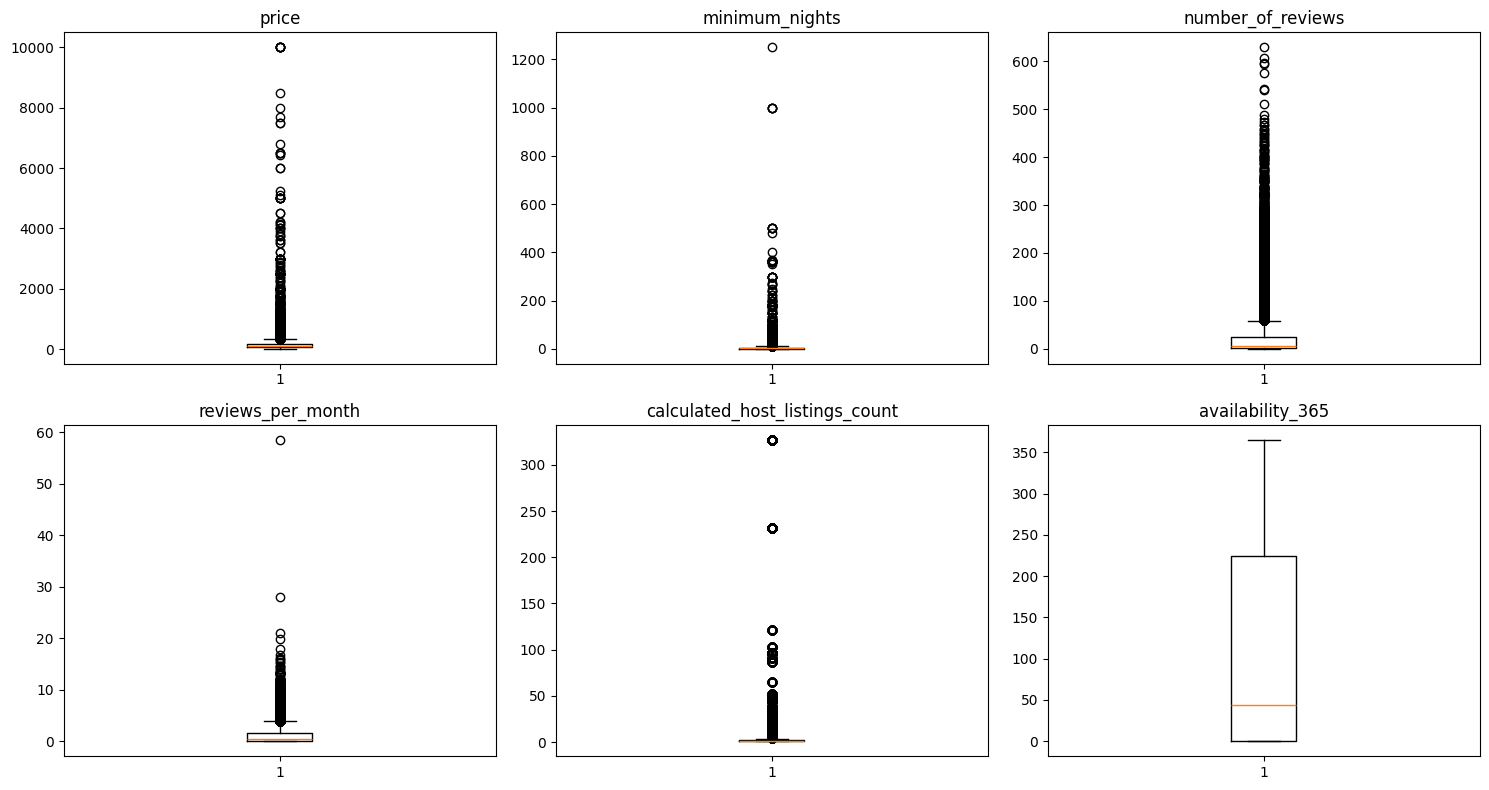

price: 2936 outliers
minimum_nights: 6466 outliers
number_of_reviews: 6021 outliers
reviews_per_month: 3207 outliers
calculated_host_listings_count: 6895 outliers
availability_365: 0 outliers


In [28]:
# box plot each numeric column and count outliers with the IQR method
outlier_columns = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for index, column in enumerate(outlier_columns):
    axes[index].boxplot(df[column])
    axes[index].set_title(column)

plt.tight_layout()
plt.show()

for column in outlier_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {len(outliers)} outliers")


In [29]:
print(df[df["minimum_nights"] > 365][["name", "room_type", "minimum_nights", "availability_365"]])

                                      name        room_type  minimum_nights  availability_365
26341      Beautiful place in Brooklyn! #2     Private room             999               249
7355   Beautiful Fully Furnished 1 bed/bth  Entire home/apt             500                90
1305   800sqft apartment with huge terrace  Entire home/apt             370               365
13404   Historic Designer 2 Bed. Apartment  Entire home/apt             999                42
11193   Zen Room in Crown Heights Brooklyn     Private room             500               365
5767      Prime W. Village location 1 bdrm  Entire home/apt            1250               365
2854                               Unknown  Entire home/apt            1000               362
8014             Wonderful Large 1 bedroom  Entire home/apt             500               362
10829  Brand New Luxury Apt Lease Takeover  Entire home/apt             480               365
14285      Peaceful apartment close to F/G     Private room 

In [30]:
print(df[df["calculated_host_listings_count"] > 100][["host_name", "calculated_host_listings_count"]].drop_duplicates())

          host_name  calculated_host_listings_count
41990  sonder (nyc)                             327
35274        kazuya                             103
18470          kara                             121
34048    blueground                             232


In [31]:
print(df[df["price"] > 5000][["name", "room_type", "neighbourhood_group", "price"]])

                                                    name        room_type neighbourhood_group     price
45666                               Gem of east Flatbush     Private room            Brooklyn  7,500.00
43009    Midtown Manhattan great location (Gramacy park)  Entire home/apt           Manhattan  5,100.00
30268  Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho  Entire home/apt           Manhattan  8,500.00
17692    Luxury 1 bedroom apt. -stunning Manhattan views  Entire home/apt            Brooklyn 10,000.00
4377                                       Film Location  Entire home/apt            Brooklyn  8,000.00
9151                 Furnished room in Astoria apartment     Private room              Queens 10,000.00
12342                Quiet, Clean, Lit @ LES & Chinatown     Private room           Manhattan  9,999.00
3537                  UWS 1BR w/backyard + block from CP  Entire home/apt           Manhattan  6,000.00
6530                                  Spanish Harlem Apt  Entire

In [32]:
# cap minimum_nights at 365 so it can't exceed a full year of availability
df["minimum_nights"] = df["minimum_nights"].clip(upper=365)

In [33]:
print(df["room_type"].value_counts())
print()
print(df["room_type"].value_counts(normalize=True) * 100)

room_type
Entire home/apt    25298
Private room       22236
Shared room         1144
Name: count, dtype: int64

room_type
Entire home/apt   51.97
Private room      45.68
Shared room        2.35
Name: proportion, dtype: float64


In [34]:
print(df["neighbourhood_group"].value_counts())
print()
print(df["neighbourhood_group"].value_counts(normalize=True) * 100)

neighbourhood_group
Manhattan        21509
Brooklyn         20060
Queens            5648
Bronx             1088
Staten Island      373
Name: count, dtype: int64

neighbourhood_group
Manhattan       44.19
Brooklyn        41.21
Queens          11.60
Bronx            2.24
Staten Island    0.77
Name: proportion, dtype: float64


# Part 4: Exploratory Data Analysis

## Numerical Analysis

price: (mean = 152.45, median = 105.00, std = 240.18)
minimum_nights: (mean = 6.89, median = 2.00, std = 17.53)
number_of_reviews: (mean = 23.37, median = 5.00, std = 44.62)
reviews_per_month: (mean = 1.10, median = 0.38, std = 1.60)
calculated_host_listings_count: (mean = 6.98, median = 1.00, std = 32.69)
availability_365: (mean = 112.12, median = 44.00, std = 131.21)


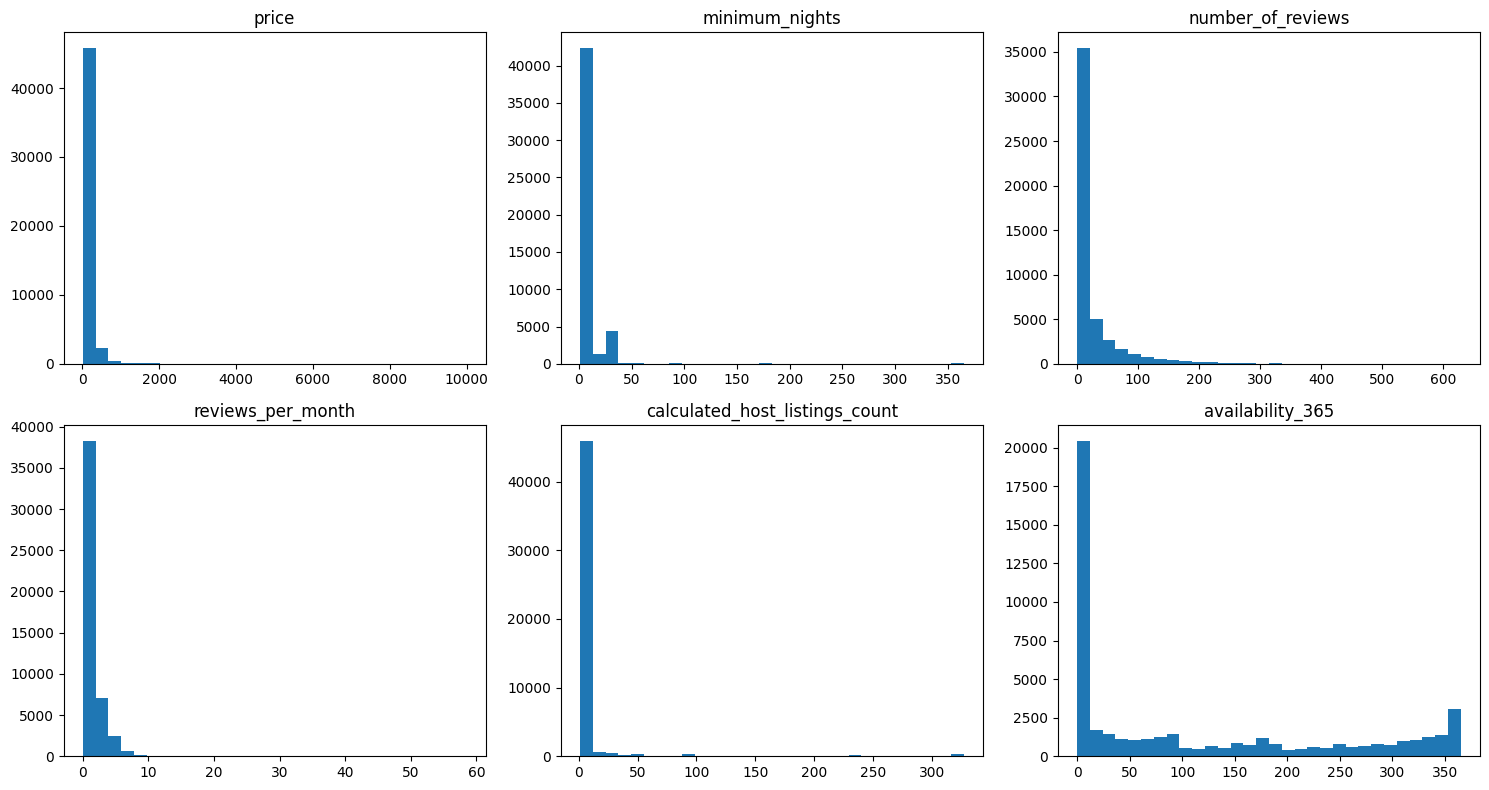

In [35]:
# compute mean/median/std and plot a histogram for each numeric column
numerical_analysis_columns = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]

for column in numerical_analysis_columns:
    mean_value = df[column].mean()
    median_value = df[column].median()
    std_value = df[column].std()

    print(f"{column}: (mean = {mean_value:.2f}, median = {median_value:.2f}, std = {std_value:.2f})")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for index, column in enumerate(numerical_analysis_columns):
    axes[index].hist(df[column], bins=30)
    axes[index].set_title(column)

plt.tight_layout()
plt.show()

All six numeric columns have mean greater than median, indicating right-skewed distributions. `price`, `number_of_reviews`, `reviews_per_month`, and `calculated_host_listings_count` are pulled up by a small number of high-value listings and hosts. `availability_365` is the least skewed and is bimodal, clustering near 0 and near 365. Median is the more representative "typical" value here, consistent with the outliers found via IQR.

## Categorical Analysis

Frequency table for room_type:
room_type
Entire home/apt    25298
Private room       22236
Shared room         1144
Name: count, dtype: int64

Percentage table for room_type:
room_type
Entire home/apt   51.97
Private room      45.68
Shared room        2.35
Name: proportion, dtype: float64



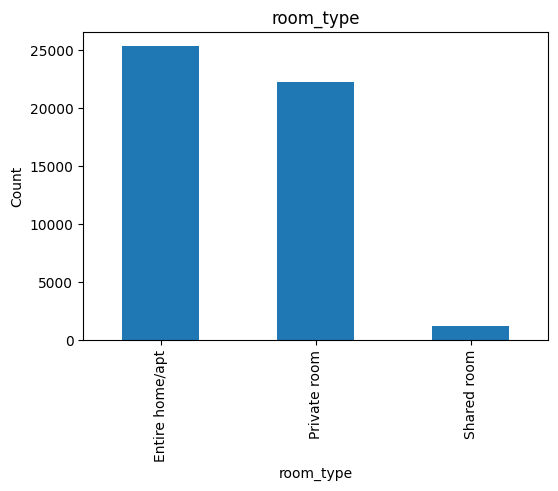

Frequency table for neighbourhood_group:
neighbourhood_group
Manhattan        21509
Brooklyn         20060
Queens            5648
Bronx             1088
Staten Island      373
Name: count, dtype: int64

Percentage table for neighbourhood_group:
neighbourhood_group
Manhattan       44.19
Brooklyn        41.21
Queens          11.60
Bronx            2.24
Staten Island    0.77
Name: proportion, dtype: float64



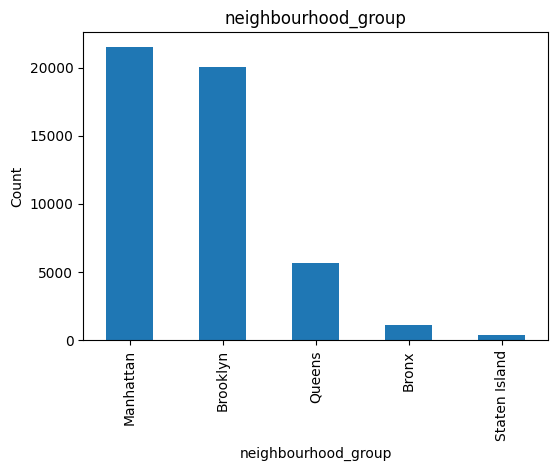

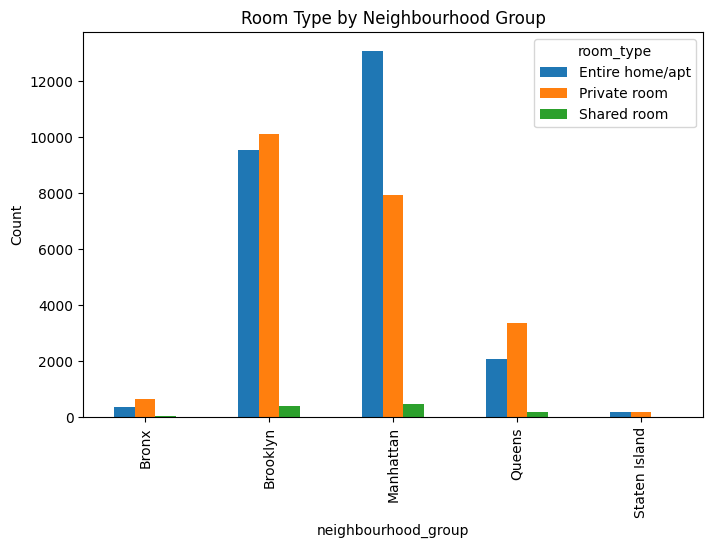

In [36]:
# build frequency/percentage tables for the categorical columns and compare room type across boroughs
categorical_analysis_columns = ["room_type", "neighbourhood_group"]

for column in categorical_analysis_columns:
    frequency_table = df[column].value_counts()
    percentage_table = df[column].value_counts(normalize=True) * 100

    print(f"Frequency table for {column}:")
    print(frequency_table)
    print()
    print(f"Percentage table for {column}:")
    print(percentage_table.round(2))
    print()

    frequency_table.plot(kind="bar", figsize=(6, 4), title=column)
    plt.ylabel("Count")
    plt.show()

category_comparison = df.groupby(["neighbourhood_group", "room_type"]).size().unstack()
category_comparison.plot(kind="bar", figsize=(8, 5), title="Room Type by Neighbourhood Group")

plt.ylabel("Count")
plt.show()

`room_type` is dominated by `Entire home/apt` and `Private room`, with `Shared room` a small minority. `neighbourhood_group` is even more skewed, Manhattan and Brooklyn alone make up over 85% of listings. The grouped comparison shows Manhattan skews toward `Entire home/apt` while outer boroughs lean more `Private room`. Any modeling on these columns needs to account for the imbalance.

## Relationship Analysis

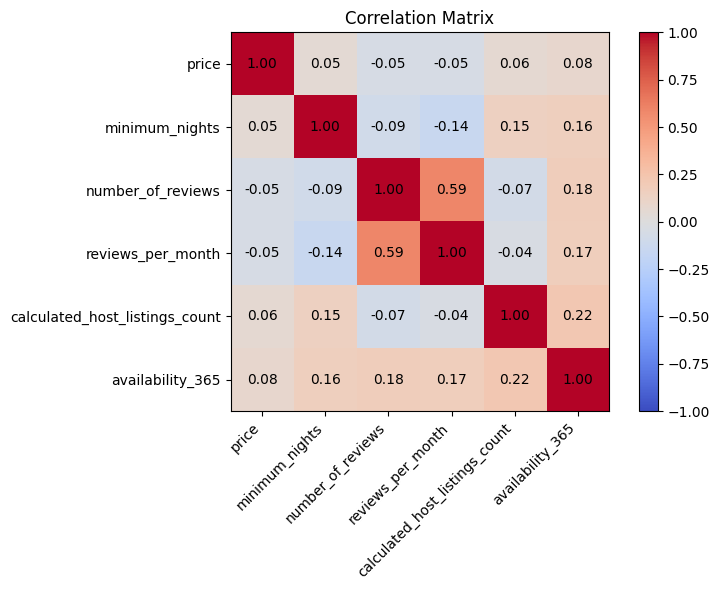

                                price  minimum_nights  number_of_reviews  reviews_per_month  calculated_host_listings_count  availability_365
price                            1.00            0.05              -0.05              -0.05                            0.06              0.08
minimum_nights                   0.05            1.00              -0.09              -0.14                            0.15              0.16
number_of_reviews               -0.05           -0.09               1.00               0.59                           -0.07              0.18
reviews_per_month               -0.05           -0.14               0.59               1.00                           -0.04              0.17
calculated_host_listings_count   0.06            0.15              -0.07              -0.04                            1.00              0.22
availability_365                 0.08            0.16               0.18               0.17                            0.22              1.00


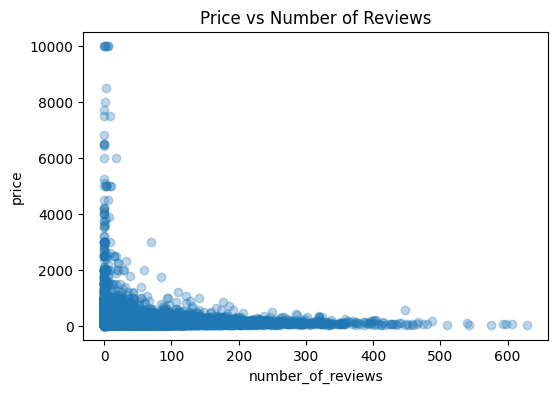

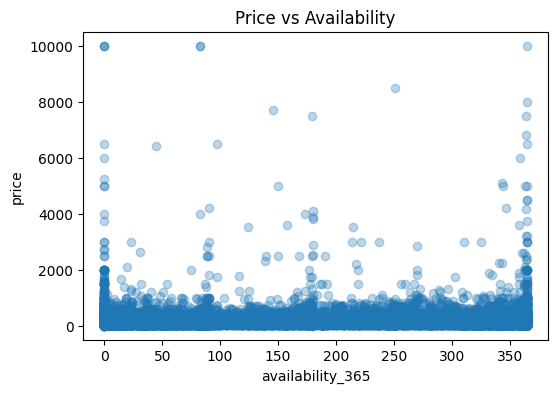

Average price by room_type:
room_type
Entire home/apt   211.34
Private room       89.66
Shared room        70.55
Name: price, dtype: float64

Average price by neighbourhood_group:
neighbourhood_group
Bronx            87.70
Brooklyn        124.53
Manhattan       196.30
Queens           99.57
Staten Island   114.81
Name: price, dtype: float64

Average price pivot table (neighbourhood_group x room_type):
room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                         127.51         67.03        59.80
Brooklyn                      178.37         76.55        50.79
Manhattan                     248.64        116.40        89.64
Queens                        147.05         71.68        69.22
Staten Island                 173.85         62.29        57.44


In [37]:
# check numeric correlations, plot price against reviews/availability, and compare average price by room type, borough, and both combined
correlation_columns = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]
correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_columns)), correlation_columns)
plt.colorbar()
plt.title("Correlation Matrix")

for row_index in range(len(correlation_columns)):
    for column_index in range(len(correlation_columns)):
        correlation_value = correlation_matrix.iloc[row_index, column_index]
        plt.text(column_index, row_index, f"{correlation_value:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

print(correlation_matrix.round(2))

plt.figure(figsize=(6, 4))
plt.scatter(df["number_of_reviews"], df["price"], alpha=0.3)
plt.xlabel("number_of_reviews")
plt.ylabel("price")
plt.title("Price vs Number of Reviews")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df["availability_365"], df["price"], alpha=0.3)
plt.xlabel("availability_365")
plt.ylabel("price")
plt.title("Price vs Availability")
plt.show()

grouped_price_by_room_type = df.groupby("room_type")["price"].mean()
print("Average price by room_type:")
print(grouped_price_by_room_type.round(2))
print()

grouped_price_by_neighbourhood_group = df.groupby("neighbourhood_group")["price"].mean()
print("Average price by neighbourhood_group:")
print(grouped_price_by_neighbourhood_group.round(2))
print()

price_pivot_table = df.pivot_table(values="price", index="neighbourhood_group", columns="room_type", aggfunc="mean")
print("Average price pivot table (neighbourhood_group x room_type):")
print(price_pivot_table.round(2))

The correlation matrix shows only weak relationships between numeric features. `price` has almost no linear correlation with any of them, all ≤ 0.08, so price is tied to categorical factors like `room_type` and `neighbourhood_group` instead.

`Entire home/apt` averages $211.34, roughly 2-3x `Private room` and `Shared room`. Manhattan averages $196.30, nearly double Brooklyn and more than double the rest.

The pivot table shows this pattern holds across every borough: `Entire home/apt` is always priciest, and Manhattan is the priciest borough for every room type. Staten Island's `Entire home/apt` price is close to Brooklyn's despite its much lower overall average, showing averages alone can hide category-level differences.

# Part 5: Data Visualization

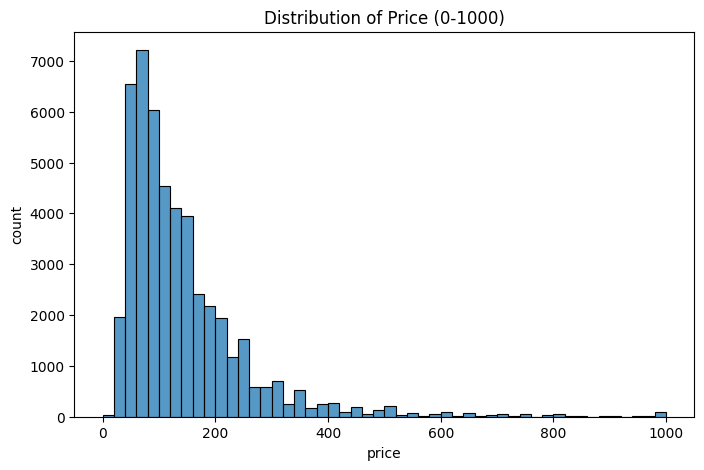

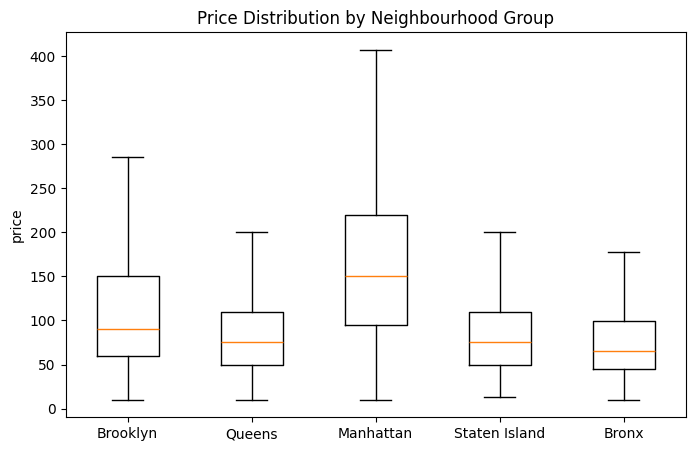

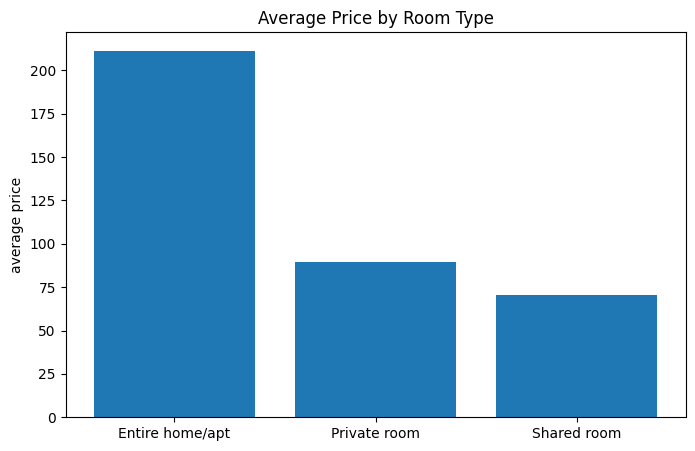

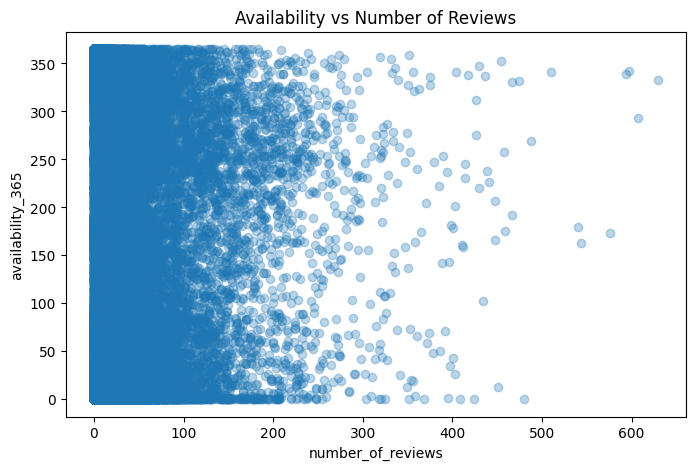

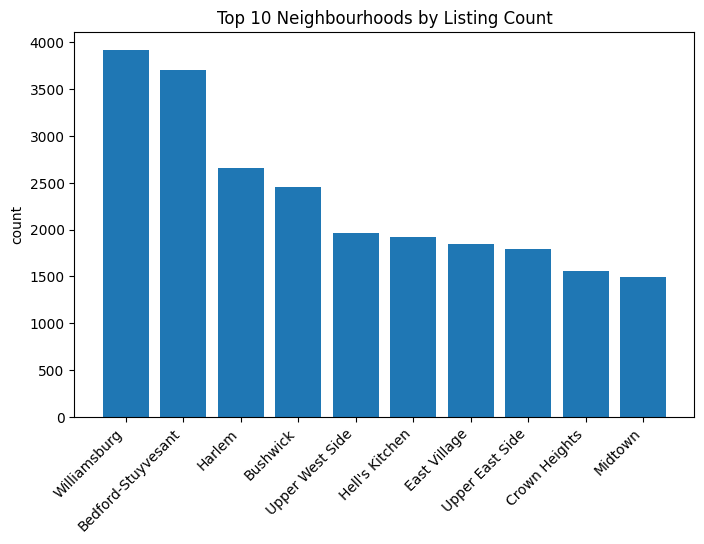

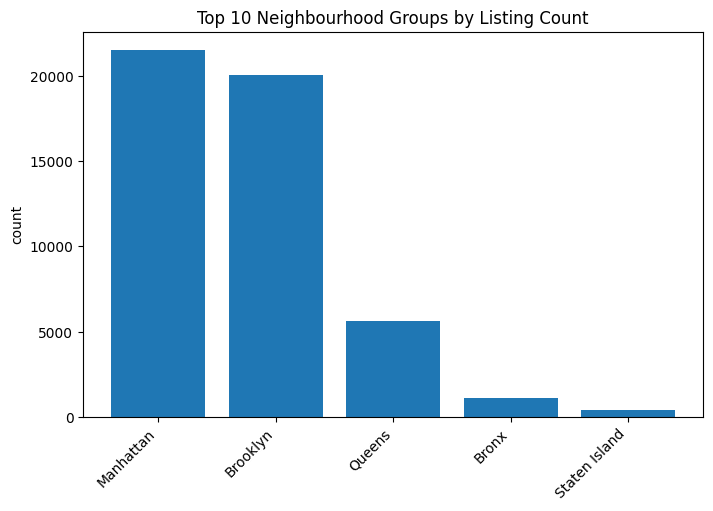

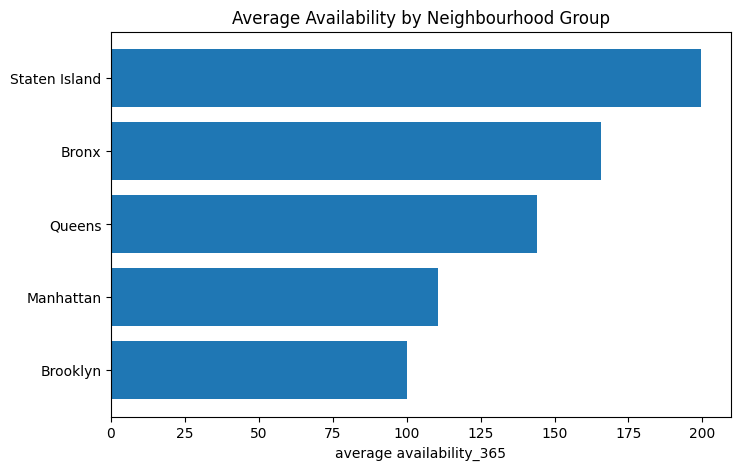

In [38]:
# the five required visualizations: price distribution, price by borough, price by room type, availability vs reviews, and top neighbourhoods
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=50, binrange=(0, 1000))
plt.xlabel("price")
plt.ylabel("count")
plt.title("Distribution of Price (0-1000)")
plt.show()

plt.figure(figsize=(8, 5))
neighbourhood_groups = df["neighbourhood_group"].unique()
price_by_group = []

for group in neighbourhood_groups:
    price_by_group.append(df[df["neighbourhood_group"] == group]["price"])

plt.boxplot(price_by_group, tick_labels=neighbourhood_groups, showfliers=False)
plt.ylabel("price")
plt.title("Price Distribution by Neighbourhood Group")
plt.show()

plt.figure(figsize=(8, 5))
average_price_by_room_type = df.groupby("room_type")["price"].mean()
plt.bar(average_price_by_room_type.index, average_price_by_room_type.values)
plt.ylabel("average price")
plt.title("Average Price by Room Type")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["number_of_reviews"], df["availability_365"], alpha=0.3)
plt.xlabel("number_of_reviews")
plt.ylabel("availability_365")
plt.title("Availability vs Number of Reviews")
plt.show()

plt.figure(figsize=(8, 5))
top_neighbourhoods = df["neighbourhood"].value_counts().head(10)
plt.bar(top_neighbourhoods.index, top_neighbourhoods.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("count")
plt.title("Top 10 Neighbourhoods by Listing Count")
plt.show()

plt.figure(figsize=(8, 5))
top_neighbourhoods = df["neighbourhood_group"].value_counts().head(10)
plt.bar(top_neighbourhoods.index, top_neighbourhoods.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("count")
plt.title("Top 10 Neighbourhood Groups by Listing Count")
plt.show()

plt.figure(figsize=(8, 5))
average_availability_by_neighbourhood_group = df.groupby("neighbourhood_group")["availability_365"].mean().sort_values()
plt.barh(average_availability_by_neighbourhood_group.index, average_availability_by_neighbourhood_group.values)
plt.xlabel("average availability_365")
plt.title("Average Availability by Neighbourhood Group")
plt.show()


---

**1. Histogram: Distribution of Price (0-1000)**
Shows price frequency, capped at $1000 to avoid luxury outliers compressing the view. Most listings are under $200 with a long right tail. Confirms the skew seen in the mean/median gap.

**2. Box Plot: Price Distribution by Neighbourhood Group**
Shows price spread by borough. Manhattan has the highest median and widest spread, Bronx and Staten Island are lower and tighter. Confirms the borough pricing pattern at a glance.

**3. Bar Chart: Average Price by Room Type**
Shows mean price per room type. `Entire home/apt` is priced far above `Private room` and `Shared room`, the premium for full-unit access.

**4. Scatter Plot: Availability vs Number of Reviews**
Shows no strong relationship between reviews and availability, matching the near-zero correlation found earlier. Confirms number_of_reviews is a weak predictor of availability.

**5. Bar Chart: Top 10 Neighbourhoods by Listing Count**
Shows the 10 busiest neighbourhoods. Listings are heavily concentrated in a few, like Williamsburg and Bedford-Stuyvesant, out of 221 total. Highlights `neighbourhood` as a high-cardinality, imbalanced feature.

---

# Part 6: Key Insights

1. Price is heavily right-skewed (mean $152.45 vs median $105). Median is the more honest "typical price" for this market.

2. Manhattan averages $196.30/night, nearly double Brooklyn and more than double every other borough. Location is one of the strongest drivers of price.

3. `Entire home/apt` costs roughly 2-3x more than `Private room` or `Shared room`. Guests pay a steep premium for full-unit privacy.

4. None of the numeric features correlate strongly with price, all under 0.08. Price is driven by location and room type, not booking behavior or host activity.

5. 217 near-duplicate listings existed, likely repeated calendar syncs or re-listings rather than distinct properties.

6. About 20% of listings have no reviews at all, a meaningful trust gap for prospective guests.

7. A small number of professional hosts (e.g. Sonder, Blueground) manage over 100 listings each, while the median host manages just 1.

8. Some listings show unrealistically high `minimum_nights` (500-1250) paired with blocked-sounding names, suggesting hosts use it as an informal pause button.

9. `room_type` and `neighbourhood_group` are both imbalanced, with Manhattan and Brooklyn holding over 85% of listings. Models need to account for this skew.

10. Listings are heavily concentrated in a small number of popular neighbourhoods rather than spread evenly across all 221.

---

# Part 7: Business Recommendations

1. Build pricing-guidance tools around location and room type, since those drive price far more than activity metrics.

2. Add a "new listing" badge or verified-host program to help the ~20% of zero-review listings compete without waiting for organic reviews.

3. Add a native pause/snooze toggle for listings, since hosts already fake this with inflated `minimum_nights` values.

4. Run targeted host-acquisition campaigns in underrepresented boroughs like Staten Island and the Bronx to diversify inventory.

5. Add a de-duplication or "possible duplicate" flag at listing-creation time to keep inventory counts accurate.

---

# Part 8: Reflection

**What was the most challenging data quality problem?**

Spotting the 217 near-duplicate listings, since there was no shared ID to group on and I had to define "duplicate" myself.

**Which decision required the most critical thinking?**

Handling the unrealistic `minimum_nights` values. The listing names showed hosts were using it as an informal pause button, so I flagged and explained the pattern instead of just cleaning it away.

**What was the most interesting finding?**

The near-zero correlation between price and every numeric feature tested. Price in this market is almost entirely explained by location and room type.

**If you repeated this project, what would you do differently?**

Run the near-duplicate check before the missing-value audit instead of after it. `duplicated()` returned 0, which made the data look clean, so I only defined a proper duplicate key later. By then the missing-value percentages had already been measured on the pre-deduplication row count.

**What did you learn about EDA from this project?**

EDA is as much about explaining why a number looks the way it does as reporting the number itself.

---

# Project Objectives:

**1. What is the purpose of this dataset?**

this dataset shows 48895 listings in Airbnb in newyork city, with reviews running upto the 8th of July 2019, across all records, only 3 types of accommodation are listed: Private room, Shared room, and Entire home/apt. this dataset can be used to study the market.

**2. What does each row represent?**

each row is a listing with information about the listed accommodation and the host who is listing it.

**3. How many rows and columns are there?**

48895 row and 16 columns

**4. Which features are numerical?**

`id`, `host_id`, `latitude`, `longitude`, `price`, `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `calculated_host_listings_count`, `availability_365`

**5. Which features are categorical?**

`name`, `host_name`, `neighbourhood_group`, `neighbourhood`, `room_type`, `last_review` (however last review is a datetime dtype and is technically not a carigorical column either)

**6. Is there a target variable? If yes, what is it?**

no there is not, but after feature engineering, the price can be a target column

**7. What did you notice immediately?**

I noticed that this dataset has no duplicates and only four columns have missing values.

**8. Are there any obvious problems?**

when I ran the describe() function, I noticed that the column minimum_nights has a max value of 1250 which is not likely, with a standard deveation of 20.51 and mean of 7.03, this indicates that the dataset has outliers and is heavily righ-skewed.

**9. Which columns require further investigation?**

last_review column has to be investigated further because it holds answers to many questions.

**10. Which columns contain missing values?**

16 nulls in name,21 nulls in host_name, 10052 nulls in both last_review and reviews_per_month, meaning that there are 10052 accommodations with no reviews.

**11. What percentage of each column is missing?**

name is 0.03% missing, host_name is 0.04% missing, last_review and reviews_per_month are both 20.34% missing. these percentages are measured after removing the 217 near-duplicates, in the raw file both were 20.56%.

**12. What is your chosen treatment?**

filled name and host_name nulls with "Unknown", filled reviews_per_month nulls with 0, and left last_review as is.

**13. Why did you choose this approach?**

`name` and `host_name` are just text labels with barely any nulls, so "Unknown" keeps the rows without inventing fake data. `reviews_per_month` nulls are replaced with zero because if there was not any reviews then the average would be zero anyway, `last_review` has no valid date to fill the listing that was never reviewed, so imputing it would be misleading, meaning it's better to leave it missing.

**14. Are duplicate rows present?**

yes, there were 217 duplicate rows.

**15. Should they be removed?**

yes

**16. Explain your decision.**

duplicate rows were replaced with a single row for each duplication, I sorted the duplicates by `last_review` and kept only the first occurance of every duplicate, that way the remaining listing has the latest available.

**17. Are any columns stored using incorrect data types?**

Yes, the `last_review` column was a wrong dtype.

**18. How did you identify them?**

when checking with `description(exclude='number')` all the columns were categorical except the `last_review`column which contained numerical digits, their dtype was object.

**19. How did you correct them?**

I assigned a new column to replace the old one with `to_datetime(df["last_review"], errors='coerce').`

**20. Identify values that are logically incorrect (e.g. negative ages, impossible ratings, invalid dates, unrealistic values). For each issue, explain how you detected it and how you treated it.**

I detected 11 prices that were = 0 by checking for prices <= 0, a free listing is not likely so I imputed them with a group based median fill, falling back from listings at the exact same coordinates to the same neighbourhood, then the same neighbourhood_group, then the same room_type on its own.

**21. Check whether categorical values are written consistently (e.g. Male / male / MALE). Describe the problem, your cleaning process, and the final result.**

All were clean except the `host_name` column, i cleaned it with lower case and strip functions.

**22. Detect outliers using appropriate techniques (such as Box Plot and IQR). How many outliers were found?**

`price:` 2936

`minimum_nights:` 6466

`number_of_reviews:` 6021

`reviews_per_month:` 3207

`calculated_host_listings_count:` 6895

`availability_365:` 0

**23. Are they real observations or possible errors?**

They are most likely real observations.

**24. Did you keep, remove, or cap them? Justify your decision.**

I only capped the `minimum_nights` column at 365 days, since the objective is to analys the dataset for actual bookable listings and I capped it at 365 to match the max availability.

**25. Is it balanced?**

No, it is not balanced.

**26. How did you measure it?**

I measured this using value_counts(normalize=True) to see the percentage share of each category.

**27. Why is this important for machine learning?**

A model trained on imbalanced classes can become biased to majority classes but perform poorly on minority ones.

---

In [52]:
# Part 9: Clustering

from sklearn.preprocessing import StandardScaler

clustering_columns = ["latitude", "longitude", "price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]

room_type_dummies = pd.get_dummies(df["room_type"], prefix="room_type")
neighbourhood_group_dummies = pd.get_dummies(df["neighbourhood_group"], prefix="neighbourhood_group")

clustering_df = pd.concat([df[clustering_columns], room_type_dummies, neighbourhood_group_dummies], axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_df)
scaled_df = pd.DataFrame(scaled_features, columns=clustering_df.columns)
scaled_df
df = df.reset_index(drop=True)

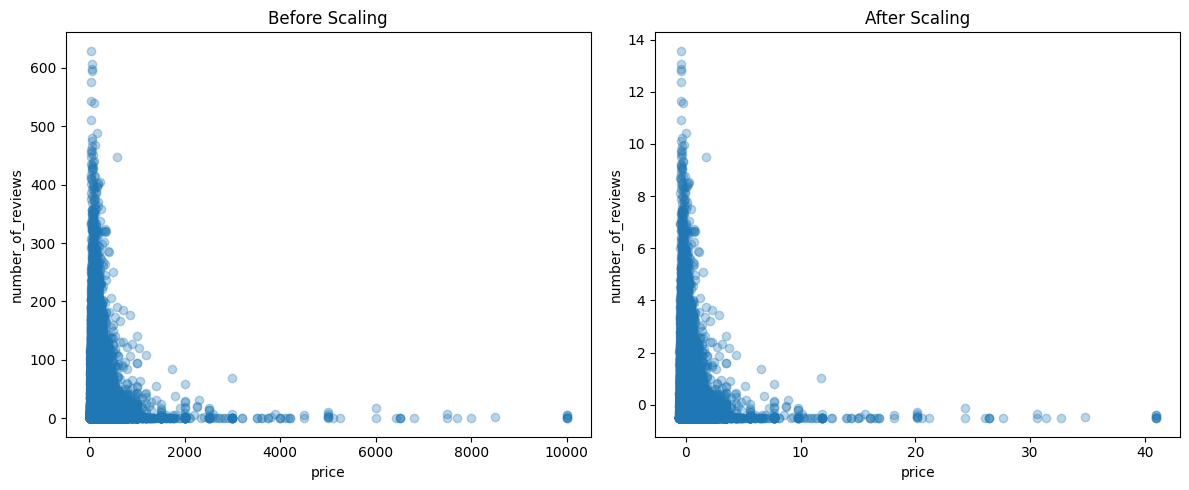

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["price"], df["number_of_reviews"], alpha=0.3)
axes[0].set_xlabel("price")
axes[0].set_ylabel("number_of_reviews")
axes[0].set_title("Before Scaling")

axes[1].scatter(scaled_df["price"], scaled_df["number_of_reviews"], alpha=0.3)
axes[1].set_xlabel("price")
axes[1].set_ylabel("number_of_reviews")
axes[1].set_title("After Scaling")

plt.tight_layout()
plt.show()

k=2: inertia=663635.21, silhouette=0.2219
k=3: inertia=580022.16, silhouette=0.2643
k=4: inertia=525089.32, silhouette=0.2935
k=5: inertia=484081.39, silhouette=0.2725
k=6: inertia=428115.07, silhouette=0.3132
k=7: inertia=395951.20, silhouette=0.3341
k=8: inertia=342361.35, silhouette=0.3438
k=9: inertia=316822.60, silhouette=0.3504
k=10: inertia=274783.09, silhouette=0.3746


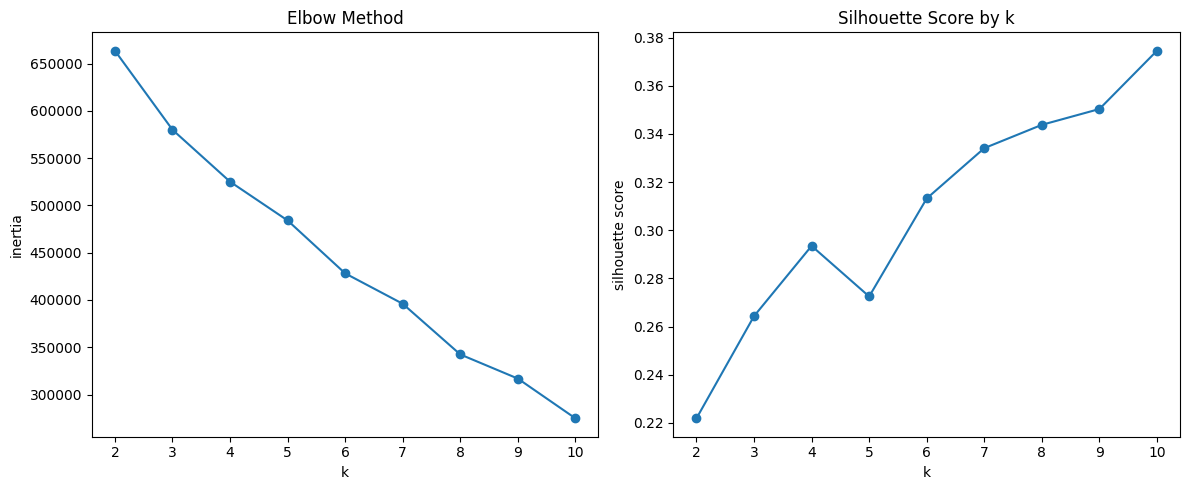

In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)
inertia_values = []
silhouette_values = []

silhouette_sample_df = scaled_df.sample(n=5000, random_state=42)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_df)
    inertia_values.append(kmeans.inertia_)

    sample_labels = kmeans.predict(silhouette_sample_df)
    silhouette_values.append(silhouette_score(silhouette_sample_df, sample_labels))

for k, inertia, silhouette in zip(k_values, inertia_values, silhouette_values):
    print(f"k={k}: inertia={inertia:.2f}, silhouette={silhouette:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(k_values), inertia_values, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_values), silhouette_values, marker="o")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

kmeans_cluster
0    20420
1    21522
2     1088
3     5648
Name: count, dtype: int64
                price  minimum_nights  number_of_reviews  reviews_per_month  calculated_host_listings_count  availability_365
kmeans_cluster                                                                                                               
0              120.84            5.95              24.39               1.06                            2.26            101.82
1              200.05            8.36              21.11               0.98                           12.47            110.76
2               87.70            4.57              26.08               1.48                            2.22            165.73
3               97.81            5.10              27.82               1.58                            4.03            144.25
room_type       Entire home/apt  Private room  Shared room
kmeans_cluster                                            
0                          0.48          

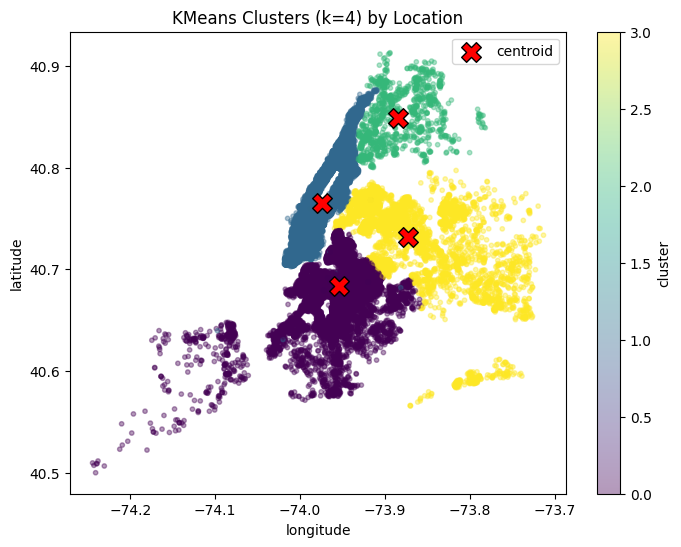

In [63]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(scaled_df)

print(df["kmeans_cluster"].value_counts().sort_index())

profile_columns = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]
cluster_profile = df.groupby("kmeans_cluster")[profile_columns].mean()
print(cluster_profile)

room_type_by_cluster = df.groupby("kmeans_cluster")["room_type"].value_counts(normalize=True).unstack().round(3)
print(room_type_by_cluster)

neighbourhood_group_by_cluster = df.groupby("kmeans_cluster")["neighbourhood_group"].value_counts(normalize=True).unstack().round(3)
print(neighbourhood_group_by_cluster)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=clustering_df.columns)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df["longitude"], df["latitude"], c=df["kmeans_cluster"], cmap="viridis", alpha=0.4, s=10)
ax.scatter(centroids_df["longitude"], centroids_df["latitude"], c="red", marker="X", s=200, edgecolors="black", label="centroid")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("KMeans Clusters (k=4) by Location")
ax.legend()
plt.colorbar(scatter, label="cluster")
plt.show()


clusters found: 25
noise points: 1382 (2.8%)
dbscan_cluster
-1      1382
 0      9973
 1      9373
 2     12308
 3      7771
 4      1933
 5      3072
 6       155
 7       123
 8       376
 9       310
 10      605
 11      147
 12      425
 13        7
 14       51
 15       16
 16      160
 17      123
 18       79
 19       22
 20       14
 21      222
 22       11
 23       10
 24       10
Name: count, dtype: int64


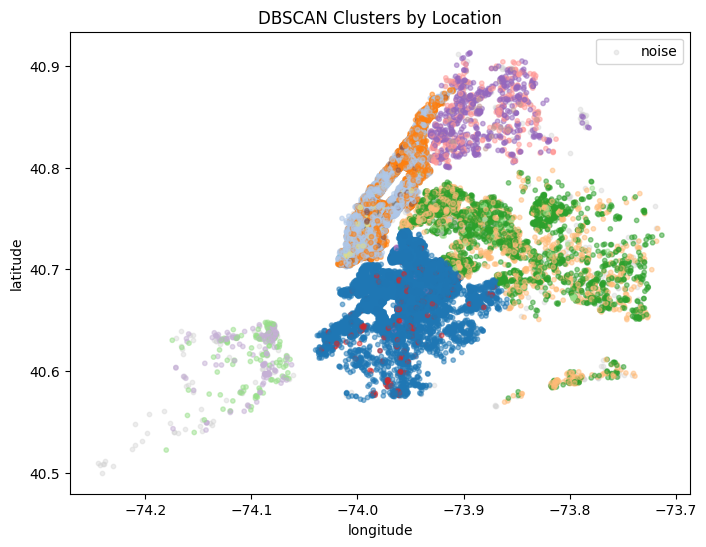

In [64]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.2, min_samples=10)
df["dbscan_cluster"] = dbscan.fit_predict(scaled_df)

n_clusters = df[df["dbscan_cluster"] != -1]["dbscan_cluster"].nunique()
n_noise = (df["dbscan_cluster"] == -1).sum()
print(f"clusters found: {n_clusters}")
print(f"noise points: {n_noise} ({n_noise / len(df) * 100:.1f}%)")

print(df["dbscan_cluster"].value_counts().sort_index())

noise_df = df[df["dbscan_cluster"] == -1]
clustered_df = df[df["dbscan_cluster"] != -1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(noise_df["longitude"], noise_df["latitude"], c="lightgray", alpha=0.4, s=10, label="noise")
scatter = ax.scatter(clustered_df["longitude"], clustered_df["latitude"], c=clustered_df["dbscan_cluster"], cmap="tab20", alpha=0.5, s=10)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("DBSCAN Clusters by Location")
ax.legend()
plt.show()


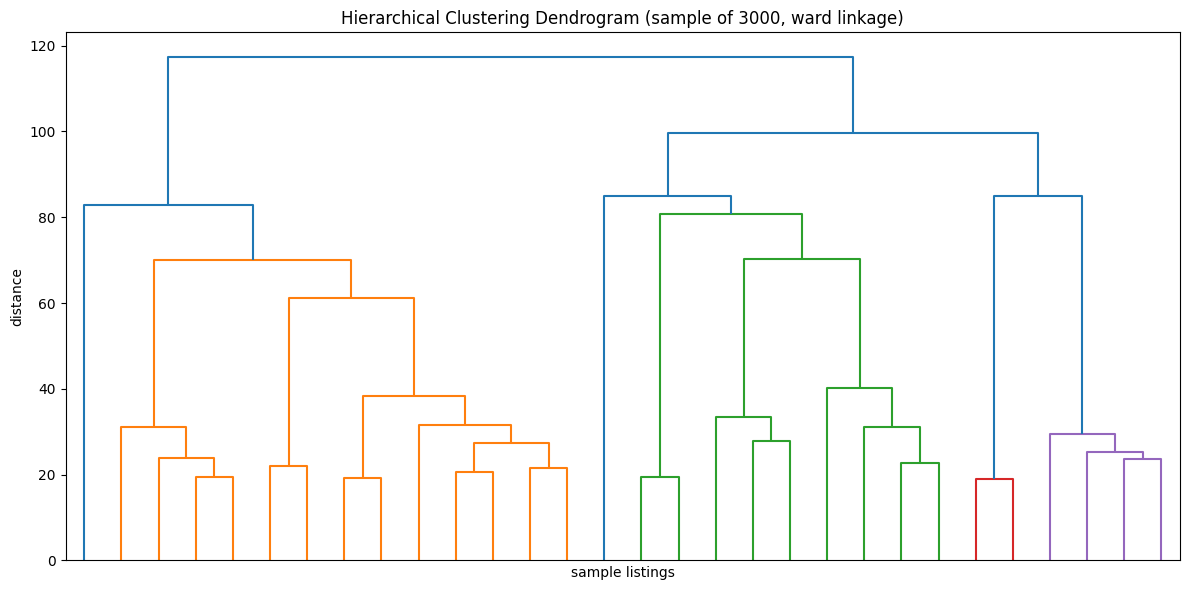

hierarchical_cluster
0    1298
1    1312
2     316
3      74
Name: count, dtype: int64
                      price  minimum_nights  number_of_reviews  reviews_per_month  calculated_host_listings_count  availability_365
hierarchical_cluster                                                                                                               
0                    115.56            5.48              25.64               1.06                            2.37            106.13
1                    199.00           10.16              18.08               0.88                           14.64            112.59
2                     92.72            4.28              27.08               1.47                            4.43            138.52
3                     70.35            6.99              20.96               0.99                            2.49            188.70
neighbourhood_group   Bronx  Brooklyn  Manhattan  Queens  Staten Island
hierarchical_cluster                             

In [57]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

hierarchical_sample_df = scaled_df.sample(n=3000, random_state=42)

linkage_matrix = linkage(hierarchical_sample_df, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=30, no_labels=True)
plt.xlabel("sample listings")
plt.ylabel("distance")
plt.title("Hierarchical Clustering Dendrogram (sample of 3000, ward linkage)")
plt.tight_layout()
plt.show()

hierarchical = AgglomerativeClustering(n_clusters=4, linkage="ward")
sample_labels = hierarchical.fit_predict(hierarchical_sample_df)

sample_original = df.loc[hierarchical_sample_df.index].copy()
sample_original["hierarchical_cluster"] = sample_labels

print(sample_original["hierarchical_cluster"].value_counts().sort_index())

profile_columns = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]
print(sample_original.groupby("hierarchical_cluster")[profile_columns].mean())
print(sample_original.groupby("hierarchical_cluster")["neighbourhood_group"].value_counts(normalize=True).unstack().round(3))


In [ ]:
borough_map_image = plt.imread("NYC-5-Boroughs-Neighborhoods-Map.jpg")

plt.figure(figsize=(7, 7))
plt.imshow(borough_map_image)
plt.axis("off")
plt.title("NYC Boroughs Reference Map")
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(df["longitude"], df["latitude"], c=df["kmeans_cluster"], cmap="viridis", alpha=0.4, s=10)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("KMeans Clusters (k=4) by Location")
plt.show()

noise_df = df[df["dbscan_cluster"] == -1]
clustered_df = df[df["dbscan_cluster"] != -1]

plt.figure(figsize=(7, 6))
plt.scatter(noise_df["longitude"], noise_df["latitude"], c="lightgray", alpha=0.4, s=10, label="noise")
plt.scatter(clustered_df["longitude"], clustered_df["latitude"], c=clustered_df["dbscan_cluster"], cmap="tab20", alpha=0.5, s=10)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("DBSCAN Clusters by Location")
plt.legend()
plt.show()


# Part 9: Clustering: Key Findings

1. All three methods (KMeans, DBSCAN, hierarchical) converge on the same dominant structure: `neighbourhood_group` (borough) is the single strongest signal in the feature space, driven by `latitude`/`longitude` plus the borough dummy columns.

2. KMeans at k=4 produces four borough-shaped clusters: Manhattan (premium, avg $200, 61% entire home), Brooklyn/Staten Island (mid-market, avg $121), Queens (budget, avg $98, private-room-heavy), and Bronx (cheapest, avg $88, smallest at 1,088 listings).

3. Silhouette score climbed steadily from k=2 to k=10 with no clear peak, so k was chosen using the local peak at k=4 plus the elbow in the inertia curve, not by chasing the highest silhouette. Higher k (e.g. k=10) only carved off tiny outlier slivers (as few as 134 rows) rather than finding meaningful new segments.

4. Log-transforming the skewed numeric columns (`price`, `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `calculated_host_listings_count`) lowered silhouette scores at every k, because it compressed the extreme outliers that were previously giving KMeans "easy," artificially well-separated clusters. Raw `StandardScaler`-only scaling was kept instead, since it's a linear transform and doesn't reshape skew on its own.

5. One-hot encoded categorical dummies (`room_type`, `neighbourhood_group`) dominate the Euclidean distance metric more than the noisier continuous features. Removing `neighbourhood_group` from the feature set caused KMeans to pivot to almost perfectly re-deriving `room_type` instead, confirming the clusters are largely re-discovering an existing categorical column rather than finding novel multivariate structure.

6. DBSCAN (`eps=1.2`, `min_samples=10`) found 25 clusters with only 2.8% of listings flagged as noise. Six clusters account for ~91% of all listings, while the rest are small, dense micro-pockets within boroughs.

7. Unlike KMeans, DBSCAN isolates a distinct set of true outlier listings as noise rather than forcing them into a borough-sized bucket, and it reveals neighborhood-level sub-structure within each borough that a fixed k=4 KMeans can't see.

8. Hierarchical clustering (Ward linkage, 4-cluster cut on a 3,000-row sample) reproduced the same borough-based 4-way split as KMeans (sizes 1298/1312/316/74, matching Brooklyn/Manhattan/Queens/Bronx), confirming the borough structure is stable across clustering algorithms rather than an artifact of KMeans specifically.

9. The k-distance graph used to tune DBSCAN's `eps` showed a gradual, indistinct elbow rather than a sharp knee, consistent with the earlier finding that the numeric features have no strong natural cluster boundaries on their own.

10. Together, the three methods reinforce the EDA's central conclusion (Part 6): location and room type explain far more variance than behavioral metrics like reviews or availability, and clustering results should be read as a location/room-type segmentation rather than a discovery of new hidden listing types.
